# This Notebook cleans the COACHE Data to select STEM faculty in general. This includes both HSI and Non-HSIs

I perform a few comparisons accross tenure

In [16]:
import pandas as pd

df = pd.read_csv('/Users/henrysalgado/COACHE_DATA/researcher-internal-maindata-2020-to-2012_HSI.csv')
df.shape


/Users/henrysalgado/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (12,43) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


(242974, 537)

df contains faculty who have complete entries and did not speed through survey

In [17]:
df= df[df['surv_speeder_status'] != 2]
df= df[df['surv_is_complete'] == 1]
df.shape

(117569, 537)

df contains only STEM faculty

In [19]:
df_stem = df[(df['demo_acarea'].isin([13,14, 16, 23]))]
df_stem.shape

(27252, 537)

1	Non-Tenure Track
2	Tenure Track
3	Tenured

In [4]:
df_stem['surv_tenure_final'].value_counts()

3.0    17489
2.0     5599
1.0     4164
Name: surv_tenure_final, dtype: int64

In [21]:
#Grabbing Instructional
df_new_inst = df_stem[(df_stem['q415']==2)]
print(len(df_new_inst))

df_new_inst['surv_tenure_final'].value_counts()
df_new_inst['demo_rank'].value_counts()
df_new_inst['hacu_hsi'].value_counts()
df_new_inst['demo_race'].value_counts()


2796


2.0     2193
1.0      279
4.0      109
3.0       83
8.0       46
6.0       38
9.0       21
91.0      20
Name: demo_race, dtype: int64

In [5]:
stem_ntt = df_stem[df_stem['surv_tenure_final'] == 1]
stem_tenure_track = df_stem[df_stem['surv_tenure_final'] == 2]
stem_tenured = df_stem[df_stem['surv_tenure_final'] == 3]
print("non tenure", stem_ntt.shape)
print("tenure track", stem_tenure_track.shape)
print("tenured", stem_tenured.shape)


non tenure (4164, 537)
tenure track (5599, 537)
tenured (17489, 537)


1	To use an offer as leverage to renegotiate the terms of my employment at [INSTITUTION]
2	To leave [INSTITUTION]

In [26]:
# Would faculty recommend their department?
print("\nPercentages (stem_ntt):")
print(stem_ntt['q265'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenure_track):")
print(stem_tenure_track['q265'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenured):")
print(stem_tenured['q265'].value_counts(normalize=True) * 100)



Percentages (stem_ntt):
2.0    54.808511
1.0    40.056738
0.0     5.134752
Name: q265, dtype: float64
Percentages (stem_tenure_track):
2.0     54.761905
1.0     34.642857
0.0      5.515873
98.0     5.079365
Name: q265, dtype: float64
Percentages (stem_tenured):
2.0     51.929163
1.0     35.430867
0.0      6.828140
98.0     5.811831
Name: q265, dtype: float64


In [45]:
# Would well you fit
print("\nPercentages (stem_ntt):")
print(stem_ntt['q205c'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenure_track):")
print(stem_tenure_track['q205c'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenured):")
print(stem_tenured['q205c'].value_counts(normalize=True) * 100)



Percentages (stem_ntt):
4.0     35.923870
5.0     23.447000
3.0     17.367169
2.0     13.164155
1.0      6.634946
98.0     2.246894
99.0     1.215966
Name: q205c, dtype: float64
Percentages (stem_tenure_track):
4.0     39.190252
5.0     30.208333
3.0     13.679245
2.0      9.728774
1.0      5.247642
98.0     1.631289
99.0     0.314465
Name: q205c, dtype: float64
Percentages (stem_tenured):
4.0     37.064331
5.0     28.915735
3.0     14.491090
2.0     10.516460
1.0      7.447901
98.0     1.304742
99.0     0.259740
Name: q205c, dtype: float64


0	There is no reason why I would choose to leave this institution 
1	To improve your salary/benefits
3	To find a more collegial work environment
4	To find an employer who provides more resources in support of your work
5	To work at an institution whose priorities match your own
6	To pursue an administrative position in higher education (e.g. chair, dean, or provost)
7	To pursue a nonacademic job
8	To improve the employment opportunities for your spouse/partner
9	For other family or personal needs
10	To improve your quality of life
11	To retire
12	To improve your prospects for promotion
13	To move to a preferred geographic location
91	Other (Please specify)
98	Decline to answer

In [27]:
# If you were to choose to leave your institution, what would be your primary reason?
print("\nPercentages (stem_ntt):")
print(stem_ntt['q260'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenure_track):")
print(stem_tenure_track['q260'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenured):")
print(stem_tenured['q260'].value_counts(normalize=True) * 100)



Percentages (stem_ntt):
1.0     21.401919
11.0    19.802772
10.0     8.022388
9.0      7.995736
13.0     6.130064
5.0      5.996802
0.0      5.437100
91.0     4.824094
98.0     4.477612
7.0      4.344350
4.0      4.051173
3.0      3.251599
8.0      2.878465
6.0      1.385928
Name: q260, dtype: float64
Percentages (stem_tenure_track):
4.0     15.456349
1.0     11.269841
13.0    11.130952
9.0     10.575397
5.0     10.178571
8.0      9.662698
10.0     7.797619
0.0      5.595238
98.0     5.178571
3.0      3.492063
11.0     2.996032
91.0     2.440476
6.0      2.142857
7.0      2.083333
Name: q260, dtype: float64
Percentages (stem_tenured):
11.0    25.229721
1.0     12.949553
4.0     10.825777
5.0     10.040772
10.0     6.803383
6.0      5.689771
13.0     5.184689
98.0     4.722205
9.0      4.618755
3.0      3.864176
0.0      3.206962
8.0      2.744478
91.0     2.288079
7.0      1.831680
Name: q260, dtype: float64


In [32]:
# Department as a place to work

print("\nPercentages (stem_ntt):")
print(stem_ntt['q45a'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenure_track):")
print(stem_tenure_track['q45a'].value_counts(normalize=True) * 100)

print("Percentages (stem_tenured):")
print(stem_tenured['q45a'].value_counts(normalize=True) * 100)



Percentages (stem_ntt):
4.0     41.820802
5.0     34.758588
99.0     9.584434
3.0      7.470574
2.0      4.443911
1.0      1.201057
98.0     0.720634
Name: q45a, dtype: float64
Percentages (stem_tenure_track):
4.0     52.296693
5.0     18.909741
3.0     14.995532
2.0     10.813226
1.0      1.983914
98.0     0.554066
99.0     0.446828
Name: q45a, dtype: float64
Percentages (stem_tenured):
4.0     51.881505
5.0     24.545351
3.0     12.284113
2.0      8.132220
1.0      1.784285
99.0     0.812078
98.0     0.560448
Name: q45a, dtype: float64


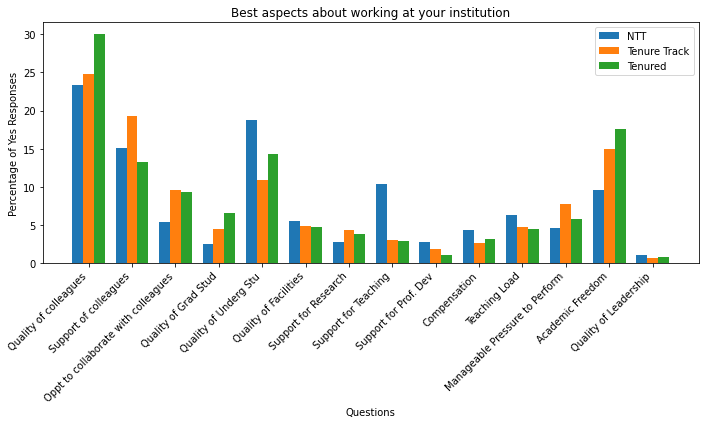

In [55]:
# Plot grouped bar chart

import matplotlib.pyplot as plt
import pandas as pd

questions = ['q267a_1', 'q267a_2', 'q267a_3', 'q267a_4', 'q267a_5', 'q267a_6','q267a_7','q267a_8','q267a_9', 'q267a_14', 'q267a_23','q267a_27', 'q267a_28','q267a_30',     ]
descriptive_names = [
    'Quality of colleagues', 
    'Support of colleagues', 
    'Oppt to collaborate with colleagues',
    'Quality of Grad Stud',
    'Quality of Underg Stu',
    'Quality of Facilities',
    'Support for Research',
    'Support for Teaching',
    'Support for Prof. Dev',
    'Compensation',
    'Teaching Load',
    'Manageable Pressure to Perform',
    'Academic Freedom',
    'Quality of Leadership'
]



ntt_percent = [stem_ntt[q].mean() * 100 for q in questions]
tenure_track_percent = [stem_tenure_track[q].mean() * 100 for q in questions]
tenured_percent = [stem_tenured[q].mean() * 100 for q in questions]


fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(questions))
width = 0.25  

ax.bar([i - width for i in x], ntt_percent, width, label="NTT")
ax.bar(x, tenure_track_percent, width, label="Tenure Track")
ax.bar([i + width for i in x], tenured_percent, width, label="Tenured")


ax.set_xlabel("Questions")
ax.set_ylabel("Percentage of Yes Responses")
ax.set_title("Best aspects about working at your institution")
ax.set_xticks(x)
ax.set_xticklabels(descriptive_names, rotation=45, ha="right")
ax.legend()


plt.tight_layout()
plt.show()

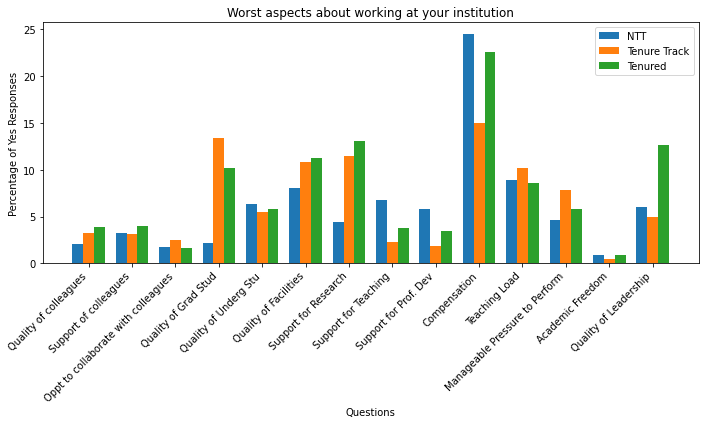

In [58]:
# Worst Aspects

import matplotlib.pyplot as plt
import pandas as pd

questions = ['q267b_1', 'q267b_2', 'q267b_3', 'q267b_4', 'q267b_5', 'q267b_6','q267b_7','q267b_8','q267b_9', 'q267b_14', 'q267b_23','q267a_27', 'q267b_28', 'q267b_30'  ]
descriptive_names = [
    'Quality of colleagues', 
    'Support of colleagues', 
    'Oppt to collaborate with colleagues',
    'Quality of Grad Stud',
    'Quality of Underg Stu',
    'Quality of Facilities',
    'Support for Research',
    'Support for Teaching',
    'Support for Prof. Dev',
    'Compensation',
    'Teaching Load',
    'Manageable Pressure to Perform',
    'Academic Freedom',
    'Quality of Leadership'
]



ntt_percent = [stem_ntt[q].mean() * 100 for q in questions]
tenure_track_percent = [stem_tenure_track[q].mean() * 100 for q in questions]
tenured_percent = [stem_tenured[q].mean() * 100 for q in questions]


fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(questions))
width = 0.25  

ax.bar([i - width for i in x], ntt_percent, width, label="NTT")
ax.bar(x, tenure_track_percent, width, label="Tenure Track")
ax.bar([i + width for i in x], tenured_percent, width, label="Tenured")


ax.set_xlabel("Questions")
ax.set_ylabel("Percentage of Yes Responses")
ax.set_title("Worst aspects about working at your institution")
ax.set_xticks(x)
ax.set_xticklabels(descriptive_names, rotation=45, ha="right")
ax.legend()


plt.tight_layout()
plt.show()